In [1]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
string = uploaded[file_name].decode('utf-8')

Saving shakespear.txt to shakespear.txt


In [2]:
vocab_ = set()
vocab = dict()
idx = 1

for char in string:
  if char not in vocab_:
    vocab_.add(char)
    vocab[char] = idx
    idx += 1


In [3]:
vocab_size = len(vocab) + 1   # + 1 for padding token
vocab_size

63

In [4]:
vocab

{'T': 1,
 'h': 2,
 'a': 3,
 't': 4,
 ',': 5,
 ' ': 6,
 'p': 7,
 'o': 8,
 'r': 9,
 'c': 10,
 'n': 11,
 'e': 12,
 'm': 13,
 'l': 14,
 'i': 15,
 "'": 16,
 'd': 17,
 'u': 18,
 's': 19,
 'f': 20,
 '\n': 21,
 'I': 22,
 'y': 23,
 'v': 24,
 ';': 25,
 'q': 26,
 'H': 27,
 'b': 28,
 'k': 29,
 'x': 30,
 'A': 31,
 'B': 32,
 'w': 33,
 'g': 34,
 'G': 35,
 '.': 36,
 'O': 37,
 'N': 38,
 'D': 39,
 'E': 40,
 'L': 41,
 ':': 42,
 'M': 43,
 'K': 44,
 'R': 45,
 'j': 46,
 'S': 47,
 '-': 48,
 'F': 49,
 'W': 50,
 'U': 51,
 'Y': 52,
 'C': 53,
 'V': 54,
 'P': 55,
 '?': 56,
 '!': 57,
 'J': 58,
 'X': 59,
 'z': 60,
 'Q': 61,
 'Z': 62}

In [5]:
string

"That, poor contempt, or claim'd thou slept so faithful,\nI may contrive our father; and, in their defeated queen,\nHer flesh broke me and puttance of expedition house,\nAnd in that same that ever I lament this stomach,\nAnd he, nor Butly and my fury, knowing everything\nGrew daily ever, his great strength and thought\nThe bright buds of mine own.\n\nBIONDELLO:\nMarry, that it may not pray their patience.'\n\nKING LEAR:\nThe instant common maid, as we may less be\na brave gentleman and joiner: he that finds us with wax\nAnd owe so full of presence and our fooder at our\nstaves. It is remorsed the bridal's man his grace\nfor every business in my tongue, but I was thinking\nthat he contends, he hath respected thee.\n\nBIRON:\nShe left thee on, I'll die to blessed and most reasonable\nNature in this honour, and her bosom is safe, some\nothers from his speedy-birth, a bill and as\nForestem with Richard in your heart\nBe question'd on, nor that I was enough:\nWhich of a partier forth the ob

In [6]:
len(string)

99985

In [7]:
batch_size = 64
seq_length = 100


sequences = []
sequence = []

for char in string:
  token = vocab[char]
  sequence.append(token)

  if len(sequence) == seq_length:
    sequences.append(sequence)
    sequence = []

if len(sequence) != 0:
  while len(sequence) != 100:
    sequence.append(0)

sequences.append(sequence)

In [8]:
len(sequences)

1000

In [11]:
batches = []     # total batches, batch size, sequence length

batch = []
for i in range(0, len(sequences), batch_size):
  print(i, i+batch_size)
  batches.append(sequences[i:i+batch_size])

0 64
64 128
128 192
192 256
256 320
320 384
384 448
448 512
512 576
576 640
640 704
704 768
768 832
832 896
896 960
960 1024


In [12]:
print(len(batches))

16


In [14]:
print(len(batches[-1]))

40


In [15]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
batches_list = []

for batch in batches:
  batch_tensor = torch.Tensor(batch)
  batches_list.append(batch_tensor.long())


In [17]:
len(batches_list)

16

In [19]:
batches_list[-1].shape

torch.Size([40, 100])

In [20]:
d_model = 128
d_h = 64


class VanillaRNN(nn.Module):

  def __init__(self):
    super().__init__()

    self.embeddings = nn.Embedding(vocab_size, d_model, padding_idx=0)

    # weights
    self.w_xh = nn.Linear(d_model, d_h)
    self.w_hh = nn.Linear(d_h, d_h)
    self.w_hy = nn.Linear(d_h, vocab_size)

    # activations
    self.gelu = nn.GELU()


  def forward(self, tokens: torch.Tensor, hidden: torch.Tensor | None = None) -> tuple[torch.Tensor, torch.Tensor]:
    X = self.embeddings(tokens)                                   # (batch_size, seq_len, 128)

    if hidden is None:
      hidden = torch.zeros(tokens.size(0), d_h).to(device)        # (batch_size, 64)

    sequence_len = tokens.size(1)
    outputs = []
    for t in range(sequence_len):
      x_t = X[:, t, :]                                            # (batch_size, 128)
      hidden = self.gelu(self.w_xh(x_t) + self.w_hh(hidden))      # (batch_size, 64)
      output = self.w_hy(hidden)                                  # (batch_size, vocab_size)
      outputs.append(output)

    # (batch_size, seq_len, vocab_size), (batch_size, 64)
    return torch.stack(outputs, dim=1), hidden


Epoch 1/20 | Loss: 2.9133
Epoch 2/20 | Loss: 2.2604
Epoch 3/20 | Loss: 2.0954
Epoch 4/20 | Loss: 2.0015
Epoch 5/20 | Loss: 1.9426
Epoch 6/20 | Loss: 1.9023
Epoch 7/20 | Loss: 1.8729
Epoch 8/20 | Loss: 1.8494
Epoch 9/20 | Loss: 1.8310
Epoch 10/20 | Loss: 1.8157
Epoch 11/20 | Loss: 1.8023
Epoch 12/20 | Loss: 1.7911
Epoch 13/20 | Loss: 1.7795
Epoch 14/20 | Loss: 1.7683
Epoch 15/20 | Loss: 1.7601
Epoch 16/20 | Loss: 1.7532
Epoch 17/20 | Loss: 1.7470
Epoch 18/20 | Loss: 1.7420
Epoch 19/20 | Loss: 1.7357
Epoch 20/20 | Loss: 1.7303


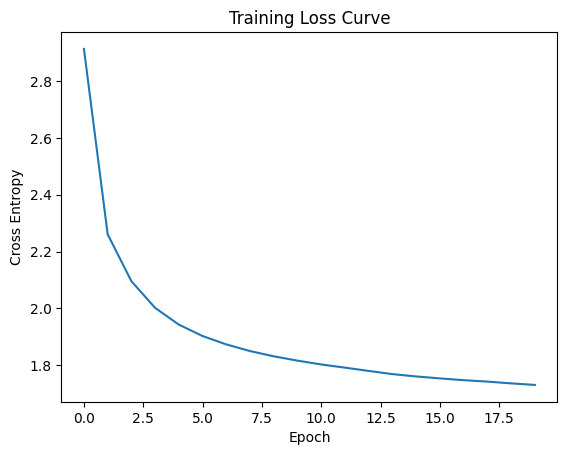

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt


train_losses = []
total_epochs = 20
LR = 0.01
PAD_TOKEN = 0

model = VanillaRNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

for epoch in range(total_epochs):
    model.train()
    total_loss = 0

    for batch in batches_list:
        inputs = batch[:, :-1].to(device)
        targets = batch[:, 1:].to(device)

        optimizer.zero_grad()

        logits, _ = model(inputs)

        # flatten for CrossEntropy: (Batch * Seq, Vocab)
        loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

        loss.backward()

        # clipping gradients to prevent exploding gradients in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(batches_list)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{total_epochs} | Loss: {avg_loss:.4f}")


plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy")
plt.show()

In [ ]:
char_to_idx_map = vocab
idx_to_char_map = {idx: char for char, idx in vocab.items()}


def char_to_idx(char):
    return char_to_idx_map.get(char, PAD_TOKEN)

def idx_to_char(char_idx):
    return idx_to_char_map.get(char_idx, "<UNK>")


def generate_with_temp(model, start_char, length, temp=1.0):
    model.eval()
    with torch.no_grad():
        current_char = torch.tensor([[char_to_idx(start_char)]]).to(device)
        hidden = None
        generated_text = start_char

        for _ in range(length):
            logits, hidden = model(current_char, hidden)

            # applying temperature to the last time step's logits
            logits = logits[:, -1, :] / max(temp, 1e-6)
            probs = torch.softmax(logits, dim=-1)

            # sampling from the distribution
            next_idx = torch.multinomial(probs, num_samples=1).item()

            generated_text += idx_to_char(next_idx)
            current_char = torch.tensor([[next_idx]]).to(device)

    return generated_text


for t in [0.7, 1.0, 1.2]:
    print(f"--- Temperature {t} ---")
    print(generate_with_temp(model, "T", 300, temp=t))
    print("--- End ---")
    print("\n")

--- Temperature 0.7 ---
Ther sure he the chilist me spent hath we make EARLININA:
Nown on and or in the confor ground, my such the morring; whos and of thry mother of a sit is do beave by that lear call the would then they, and the shall het, and this shall daise have not fore thrir the upon the station and the post to this
--- End ---


--- Temperature 1.0 ---
TRINADANAT
Will thon a lied. Blishow! and as you honcere
And huso's waurs; and the toening in vired.

PIULIN:
To were nat to so, thfor I dascesmy me love makh kitcching my pasto; no in he is onom 'dops tith from so at is in in to the wrum,
Here more apsienty exespo with them! thy halter; be feads hec
--- End ---


--- Temperature 1.2 ---
TIDGHANINDR:
Ay the prause beopht to her.

SASSANDE OF Rriness I should.

QILOFS ncrry wroming,
I am now, asor' lets in ences the at,
Allmune agaie,
Bifing his sparsod; liviver
Wite the bus to the praing futvoughn find Stasber whore go ever
Thy reathy:
Ilet butland, youtstrerry,
The juchis is st